# Clustering y Reducción de Dimensionalidad en un Portafolio de Inversiones

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from scipy.optimize import minimize
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

In [3]:
tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "TSLA", "AVGO", "ORCL", "CRM",
    "JPM", "BAC", "GS", "MS", "WFC",
    "V", "MA", "AXP", "BLK", "C",
    "JNJ", "PFE", "MRK", "ABBV", "LLY",
    "UNH", "TMO", "ABT", "MDT", "BMY",
    "XOM", "CVX", "COP", "SLB", "EOG",
    "WMT", "COST", "HD", "MCD", "NKE",
    "KO", "PEP", "PG", "CL", "KMB",
    "CAT", "BA", "GE", "UPS", "HON"
]

In [4]:
precios = yf.download(
    tickers,
    period="5y",
    interval="1d",
    auto_adjust=True,
    progress=False
)["Close"]

precios.head()

Ticker,AAPL,ABBV,ABT,AMZN,AVGO,AXP,BA,BAC,BLK,BMY,...,PG,SLB,TMO,TSLA,UNH,UPS,V,WFC,WMT,XOM
2021-08-16,147.398087,98.557419,113.108040,164.949493,44.439430,155.976135,229.059998,36.531811,819.872864,55.961605,...,127.204277,24.893658,546.760071,228.723328,382.167023,157.222168,226.610504,43.744164,47.316517,47.250351
2021-08-17,146.490997,99.597839,114.042595,162.098007,43.579113,154.940979,222.220001,36.354866,806.336792,56.189762,...,127.415352,24.364962,548.584167,221.903336,386.353119,157.772644,225.811325,43.124420,47.300819,46.929382
2021-08-18,142.755325,97.625198,112.445686,160.061005,42.694218,152.569611,219.000000,36.089432,799.502136,55.350502,...,126.025826,24.024443,537.096008,229.663330,382.267822,155.411194,223.019165,42.469284,46.798611,45.941120
2021-08-19,143.086914,98.157883,114.069809,159.387497,43.109352,149.652390,212.160004,35.558571,801.159851,55.823105,...,127.512070,23.692888,544.215759,224.490005,391.950012,154.820786,222.961380,41.831852,47.115635,44.538982
2021-08-20,144.540268,98.898659,114.614204,159.997498,43.258656,150.329910,212.669998,35.717823,813.029419,56.385326,...,127.599998,23.710802,547.292480,226.753326,393.617157,154.981201,222.759201,41.982346,47.536217,44.547443


## Retornos

In [5]:
retornos = precios.pct_change().dropna()

print("Dimensiones:", retornos.shape)
retornos.head()

Dimensiones: (1254, 50)


Ticker,AAPL,ABBV,ABT,AMZN,AVGO,AXP,BA,BAC,BLK,BMY,...,PG,SLB,TMO,TSLA,UNH,UPS,V,WFC,WMT,XOM
2021-08-17,-0.006154,0.010556,0.008262,-0.017287,-0.019359,-0.006637,-0.029861,-0.004844,-0.016510,0.004077,...,0.001659,-0.021238,0.003336,-0.029818,0.010954,0.003501,-0.003527,-0.014167,-0.000332,-0.006793
2021-08-18,-0.025501,-0.019806,-0.014003,-0.012566,-0.020305,-0.015305,-0.014490,-0.007301,-0.008476,-0.014936,...,-0.010905,-0.013976,-0.020941,0.034970,-0.010574,-0.014967,-0.012365,-0.015192,-0.010617,-0.021058
2021-08-19,0.002323,0.005456,0.014444,-0.004208,0.009723,-0.019121,-0.031233,-0.014710,0.002073,0.008538,...,0.011793,-0.013801,0.013256,-0.022526,0.025328,-0.003799,-0.000259,-0.015009,0.006774,-0.030520
2021-08-20,0.010157,0.007547,0.004772,0.003827,0.003463,0.004527,0.002404,0.004479,0.014815,0.010071,...,0.000690,0.000756,0.005653,0.010082,0.004253,0.001036,-0.000907,0.003598,0.008927,0.000190
2021-08-23,0.010257,0.004545,-0.003800,0.020600,0.015321,0.004382,0.031645,0.013376,0.011655,-0.003757,...,-0.005100,0.038927,-0.004306,0.038280,-0.010123,-0.001242,0.012016,0.004007,-0.006603,0.041145


## Resumen estadístico

In [6]:
def resumen_estadistico(retornos):
    
    resumen = pd.DataFrame({
        "Media": retornos.mean(),
        "Mediana": retornos.median(),
        "Desv_Estandar": retornos.std(),
        "Asimetria": retornos.skew(),
        "Kurtosis": retornos.kurtosis()
    })
    
    return resumen

resumen = resumen_estadistico(retornos)

resumen.head(10)

,Media,Mediana,Desv_Estandar,Asimetria,Kurtosis
Ticker,,,,,
AAPL,0.000736,0.001082,0.017669,0.380730,6.648722
ABBV,0.000851,0.000912,0.014787,-0.866247,7.210427
ABT,0.000094,0.000226,0.014440,-0.049317,6.402439
AMZN,0.000634,0.000318,0.022923,0.369224,5.715325
AVGO,0.002120,0.000854,0.027819,0.715637,8.942028
AXP,0.000799,0.000675,0.018601,0.110435,5.411056
BA,0.000275,0.000070,0.023134,0.087114,3.623000
BAC,0.000594,0.000481,0.016765,-0.046242,3.538103
BLK,0.000432,0.000366,0.017018,0.383842,5.580435


In [7]:
mercado = yf.download(
    "^GSPC",
    period="5y",
    interval="1d",
    auto_adjust=True,
    progress=False
)["Close"]

ret_mercado = mercado.pct_change().dropna()

ret_mercado.head()

Ticker,^GSPC
2021-08-17,-0.007061
2021-08-18,-0.010748
2021-08-19,0.001257
2021-08-20,0.008142
2021-08-23,0.008524


In [8]:
def calcular_betas(retornos, ret_mercado):
    
    betas = {}
    
    for ticker in retornos.columns:
        
        datos = pd.concat(
            [retornos[ticker], ret_mercado],
            axis=1
        ).dropna()
        
        datos.columns = ["activo", "mercado"]
        
        beta = datos["activo"].cov(datos["mercado"]) / datos["mercado"].var()
        
        betas[ticker] = beta
    
    return pd.Series(betas, name="Beta")


betas = calcular_betas(retornos, ret_mercado)

betas.sort_values()

JNJ      0.163834
KMB      0.207071
CL       0.212781
KO       0.263670
MRK      0.273102
BMY      0.279782
PEP      0.282833
PG       0.289721
ABBV     0.302165
MCD      0.363168
PFE      0.399158
WMT      0.409407
XOM      0.409841
UNH      0.422306
CVX      0.473865
ABT      0.505213
MDT      0.530974
EOG      0.569428
LLY      0.578127
COP      0.605126
COST     0.697848
HON      0.783617
V        0.808819
SLB      0.833076
HD       0.838683
UPS      0.852425
TMO      0.852890
JPM      0.886692
MA       0.888462
BAC      0.963857
WFC      0.982919
CAT      1.065528
NKE      1.069836
GE       1.085196
C        1.104776
MSFT     1.146771
BA       1.150688
GS       1.157674
AXP      1.174825
MS       1.176038
BLK      1.189534
AAPL     1.191440
ORCL     1.225826
CRM      1.239262
GOOGL    1.266243
AMZN     1.508743
META     1.609027
AVGO     1.665435
TSLA     2.049801
NVDA     2.171874
Name: Beta, dtype: float64

In [9]:
def clasificar_beta(beta):
    if beta < 0.8:
        return "Baja"
    elif beta <= 1.2:
        return "Media"
    else:
        return "Alta"


resumen["Beta"] = betas
resumen["Nivel_Beta"] = resumen["Beta"].apply(clasificar_beta)

resumen.sort_values("Beta")

,Media,Mediana,Desv_Estandar,Asimetria,Kurtosis,Beta,Nivel_Beta
Ticker,,,,,,,
JNJ,0.000479,0.000337,0.011004,0.129981,4.332559,0.163834,Baja
KMB,0.000060,0.000331,0.013078,-1.066059,14.649412,0.207071,Baja
CL,0.000281,0.000381,0.011987,-0.211804,1.843092,0.212781,Baja
KO,0.000510,0.000570,0.010481,-0.046891,3.566072,0.263670,Baja
MRK,0.000677,0.000630,0.015206,-0.241981,5.967942,0.273102,Baja
BMY,0.000226,-0.000149,0.015459,0.408745,5.918330,0.279782,Baja
PEP,0.000104,0.000092,0.011868,0.020289,3.116111,0.282833,Baja
PG,0.000166,0.000643,0.011401,-0.362069,2.573198,0.289721,Baja
ABBV,0.000851,0.000912,0.014787,-0.866247,7.210427,0.302165,Baja


In [10]:
resumen["Nivel_Beta"].value_counts()

Nivel_Beta
Baja     22
Media    20
Alta      8
Name: count, dtype: int64

# Matriz de correlaciones

In [11]:
matriz_corr = retornos.corr()

matriz_corr

Ticker,AAPL,ABBV,ABT,AMZN,AVGO,AXP,BA,BAC,BLK,BMY,...,PG,SLB,TMO,TSLA,UNH,UPS,V,WFC,WMT,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.137141,0.274728,0.494116,0.416425,0.447147,0.381074,0.381256,0.532172,0.124414,...,0.250474,0.226867,0.347286,0.465451,0.108270,0.379251,0.465758,0.343180,0.260378,0.172072
ABBV,0.137141,1.000000,0.317137,0.018324,0.017481,0.165161,0.084661,0.192042,0.172464,0.400442,...,0.332104,0.115722,0.305387,-0.005643,0.187220,0.211214,0.254554,0.178365,0.213255,0.161286
ABT,0.274728,0.317137,1.000000,0.189002,0.062817,0.256758,0.190115,0.280121,0.350141,0.267162,...,0.387166,0.090846,0.423320,0.076201,0.170288,0.280686,0.383720,0.239200,0.225211,0.101447
AMZN,0.494116,0.018324,0.189002,1.000000,0.433447,0.448916,0.373253,0.367951,0.490593,0.041350,...,0.096585,0.176562,0.326590,0.440530,0.082643,0.325778,0.382093,0.335205,0.201667,0.079837
AVGO,0.416425,0.017481,0.062817,0.433447,1.000000,0.354417,0.308452,0.261613,0.400777,-0.043248,...,-0.014377,0.177792,0.246068,0.415484,0.029383,0.212148,0.256611,0.251040,0.096235,0.057108
AXP,0.447147,0.165161,0.256758,0.448916,0.354417,1.000000,0.459004,0.682236,0.620923,0.167878,...,0.167243,0.333549,0.392251,0.402017,0.181005,0.394065,0.576162,0.652232,0.191507,0.247325
BA,0.381074,0.084661,0.190115,0.373253,0.308452,0.459004,1.000000,0.403604,0.445614,0.065696,...,0.113138,0.270487,0.231019,0.340194,0.107068,0.290086,0.315437,0.390248,0.178089,0.164429
BAC,0.381256,0.192042,0.280121,0.367951,0.261613,0.682236,0.403604,1.000000,0.633762,0.186913,...,0.174457,0.377660,0.346708,0.331832,0.160901,0.416495,0.457035,0.817664,0.196902,0.307915
BLK,0.532172,0.172464,0.350141,0.490593,0.400777,0.620923,0.445614,0.633762,1.000000,0.186110,...,0.260362,0.328011,0.438510,0.389575,0.183004,0.436628,0.505257,0.567252,0.235540,0.213657


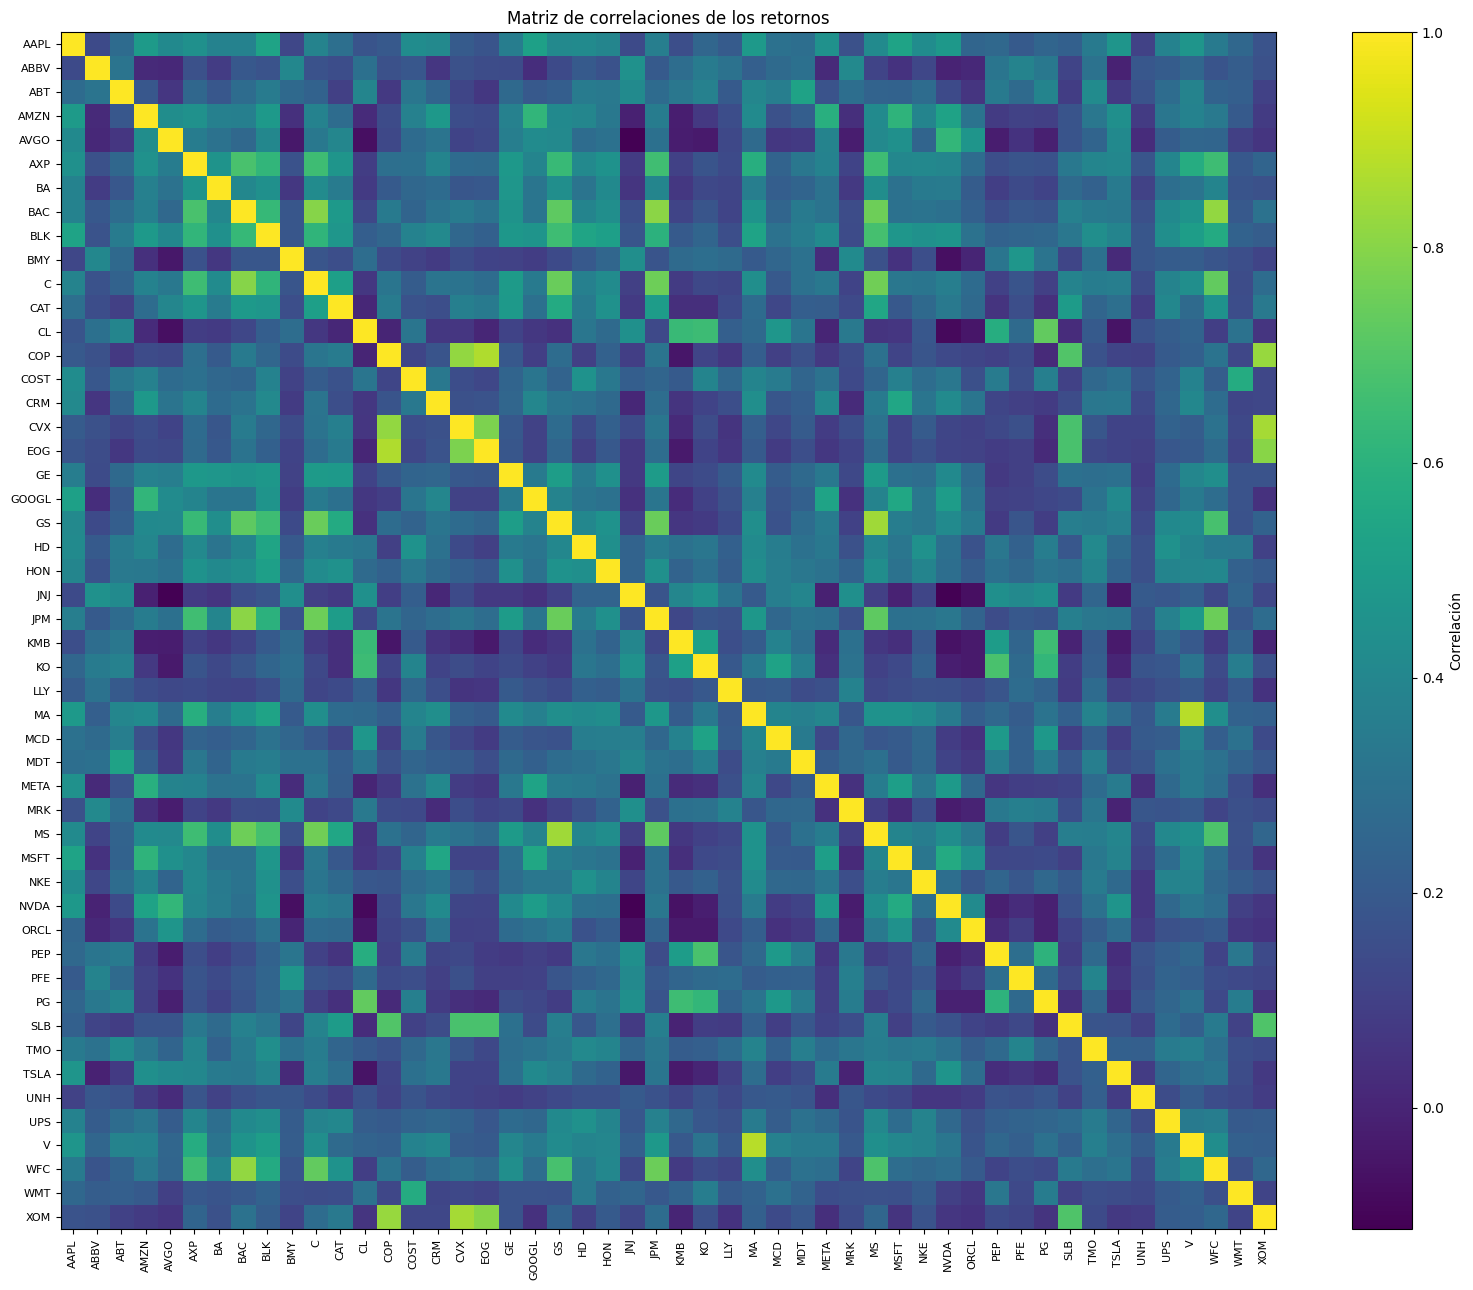

In [12]:
plt.figure(figsize=(16, 13))

plt.imshow(matriz_corr, aspect="auto")
plt.colorbar(label="Correlación")

plt.xticks(
    range(len(matriz_corr.columns)),
    matriz_corr.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(matriz_corr.index)),
    matriz_corr.index,
    fontsize=8
)

plt.title("Matriz de correlaciones de los retornos")
plt.tight_layout()
plt.show()

In [13]:
corr_pares = matriz_corr.where(
    np.triu(np.ones(matriz_corr.shape), k=1).astype(bool)
).stack()

print("5 correlaciones más bajas:")
display(corr_pares.nsmallest(5))

print("5 correlaciones más altas:")
display(corr_pares.nlargest(5))

5 correlaciones más bajas:


Ticker  Ticker
JNJ     NVDA     -0.112882
AVGO    JNJ      -0.108896
CL      NVDA     -0.085482
AVGO    CL       -0.068893
BMY     NVDA     -0.067254
dtype: float64

5 correlaciones más altas:


Ticker  Ticker
MA      V         0.880990
COP     EOG       0.869515
CVX     XOM       0.847991
GS      MS        0.840446
COP     XOM       0.829883
dtype: float64

La matriz de correlaciones muestra que existe una relación positiva entre gran parte de los activos, aunque su intensidad varía. También se observan algunos pares con correlaciones bajas e incluso negativas, como JNJ–NVDA y AVGO–JNJ. Estos activos pueden ser útiles para diversificar el portafolio, ya que sus retornos tienden a presentar movimientos menos similares. Por otro lado, las correlaciones más altas indican activos que presentan comportamientos más parecidos, por lo que combinarlos aporta un menor beneficio de diversificación.

## PCA + Clustering

In [14]:
X = retornos.T

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dimensiones originales:", X.shape)
print("Dimensiones estandarizadas:", X_scaled.shape)

Dimensiones originales: (50, 1254)
Dimensiones estandarizadas: (50, 1254)


In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=retornos.columns
)

pca_df.head()

,PC1,PC2
Ticker,,
AAPL,-8.542187,3.916773
ABBV,14.177566,7.709965
ABT,8.564415,10.275506
AMZN,-20.320220,4.549985
AVGO,-27.240421,-0.649294


In [16]:
varianza = pca.explained_variance_ratio_

print("Varianza explicada PC1:", round(varianza[0], 4))
print("Varianza explicada PC2:", round(varianza[1], 4))
print("Varianza explicada total:", round(varianza.sum(), 4))

Varianza explicada PC1: 0.1616
Varianza explicada PC2: 0.1031
Varianza explicada total: 0.2647


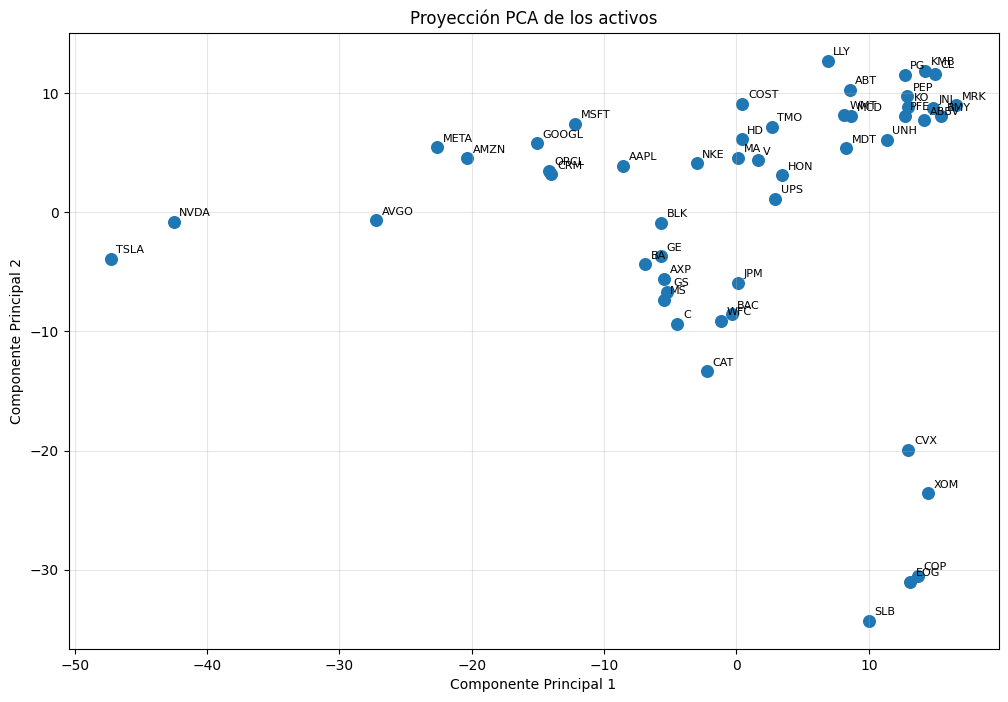

In [17]:
plt.figure(figsize=(12, 8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=70
)

for ticker in pca_df.index:
    plt.annotate(
        ticker,
        (pca_df.loc[ticker, "PC1"],
         pca_df.loc[ticker, "PC2"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Proyección PCA de los activos")
plt.grid(alpha=0.3)
plt.show()

In [18]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

pca_df["KMeans"] = kmeans.fit_predict(X_scaled)

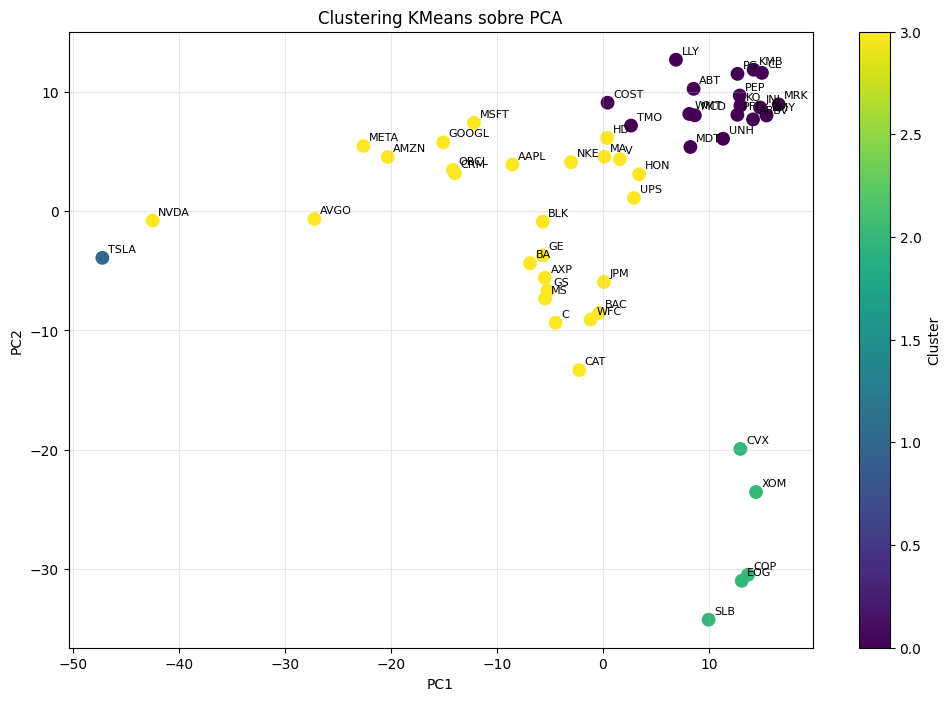

In [19]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["KMeans"],
    s=80
)

for ticker in pca_df.index:
    plt.annotate(
        ticker,
        (pca_df.loc[ticker, "PC1"],
         pca_df.loc[ticker, "PC2"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering KMeans sobre PCA")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

In [20]:
for cluster in sorted(pca_df["KMeans"].unique()):
    activos = pca_df[pca_df["KMeans"] == cluster].index.tolist()
    
    print(f"\nCluster {cluster}:")
    print(activos)


Cluster 0:
['ABBV', 'ABT', 'BMY', 'CL', 'COST', 'JNJ', 'KMB', 'KO', 'LLY', 'MCD', 'MDT', 'MRK', 'PEP', 'PFE', 'PG', 'TMO', 'UNH', 'WMT']

Cluster 1:
['TSLA']

Cluster 2:
['COP', 'CVX', 'EOG', 'SLB', 'XOM']

Cluster 3:
['AAPL', 'AMZN', 'AVGO', 'AXP', 'BA', 'BAC', 'BLK', 'C', 'CAT', 'CRM', 'GE', 'GOOGL', 'GS', 'HD', 'HON', 'JPM', 'MA', 'META', 'MS', 'MSFT', 'NKE', 'NVDA', 'ORCL', 'UPS', 'V', 'WFC']


In [21]:
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(
    pca_df[["PC1", "PC2"]]
)

dbscan = DBSCAN(
    eps=0.7,
    min_samples=3
)

pca_df["DBSCAN"] = dbscan.fit_predict(X_pca_scaled)

pca_df["DBSCAN"].value_counts().sort_index()

DBSCAN
-1     2
 0    43
 1     5
Name: count, dtype: int64

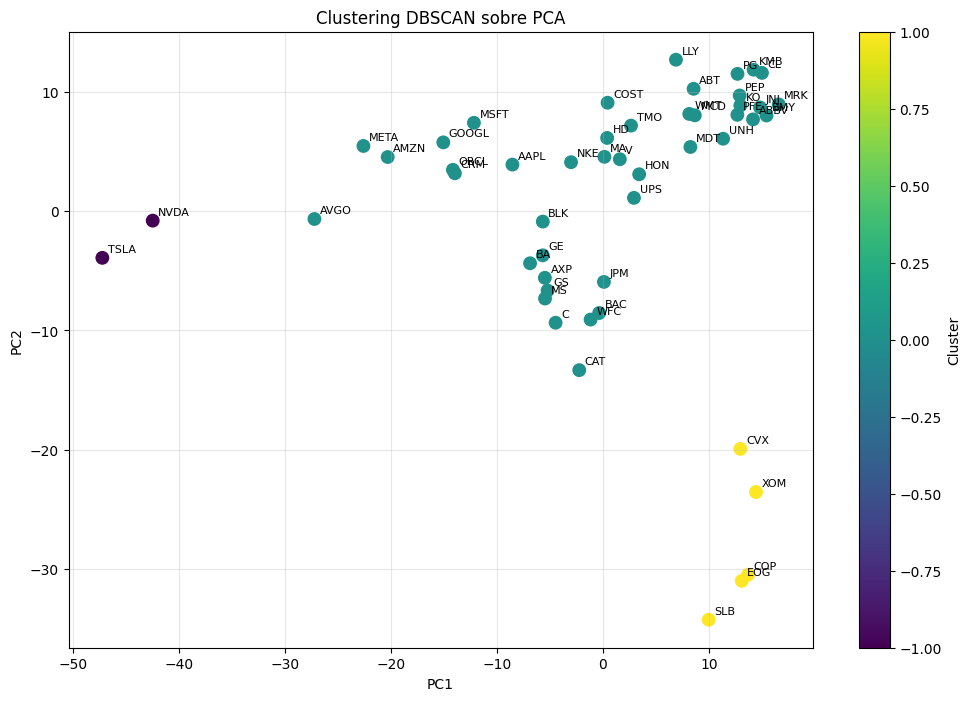

In [22]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["DBSCAN"],
    s=80
)

for ticker in pca_df.index:
    plt.annotate(
        ticker,
        (pca_df.loc[ticker, "PC1"],
         pca_df.loc[ticker, "PC2"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering DBSCAN sobre PCA")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

In [23]:
for cluster in sorted(pca_df["DBSCAN"].unique()):

    activos = pca_df[
        pca_df["DBSCAN"] == cluster
    ].index.tolist()

    if cluster == -1:
        print("\nRuido / valores atípicos:")
    else:
        print(f"\nCluster {cluster}:")

    print(activos)


Ruido / valores atípicos:
['NVDA', 'TSLA']

Cluster 0:
['AAPL', 'ABBV', 'ABT', 'AMZN', 'AVGO', 'AXP', 'BA', 'BAC', 'BLK', 'BMY', 'C', 'CAT', 'CL', 'COST', 'CRM', 'GE', 'GOOGL', 'GS', 'HD', 'HON', 'JNJ', 'JPM', 'KMB', 'KO', 'LLY', 'MA', 'MCD', 'MDT', 'META', 'MRK', 'MS', 'MSFT', 'NKE', 'ORCL', 'PEP', 'PFE', 'PG', 'TMO', 'UNH', 'UPS', 'V', 'WFC', 'WMT']

Cluster 1:
['COP', 'CVX', 'EOG', 'SLB', 'XOM']


In [24]:
jerarquico = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

pca_df["Jerarquico"] = jerarquico.fit_predict(X_scaled)

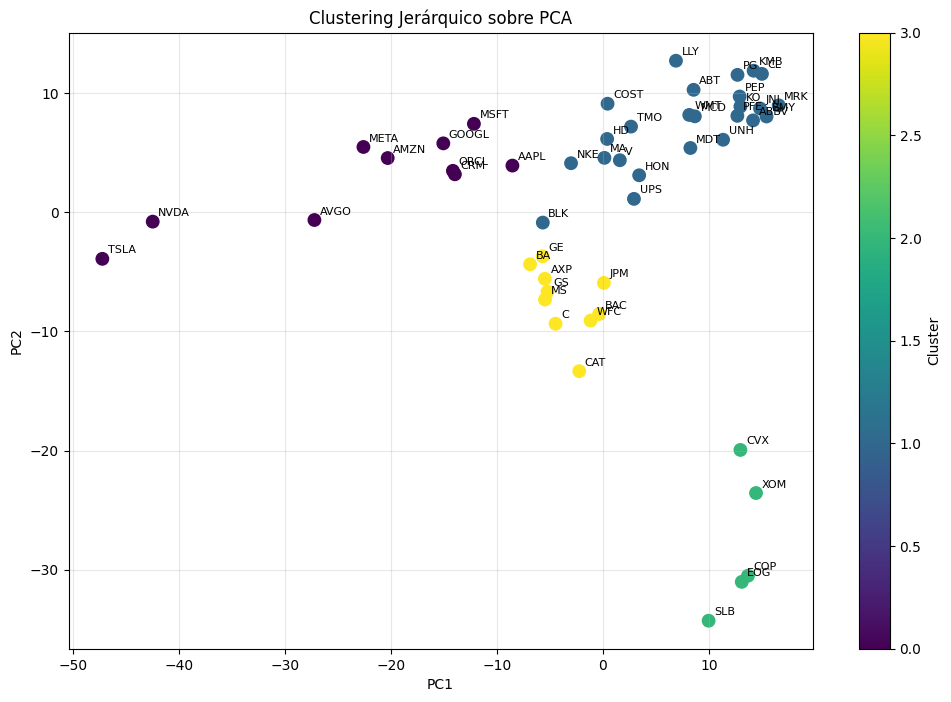

In [25]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Jerarquico"],
    s=80
)

for ticker in pca_df.index:
    plt.annotate(
        ticker,
        (pca_df.loc[ticker, "PC1"],
         pca_df.loc[ticker, "PC2"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering Jerárquico sobre PCA")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

In [26]:
for cluster in sorted(pca_df["Jerarquico"].unique()):

    activos = pca_df[
        pca_df["Jerarquico"] == cluster
    ].index.tolist()

    print(f"\nCluster {cluster}:")
    print(activos)


Cluster 0:
['AAPL', 'AMZN', 'AVGO', 'CRM', 'GOOGL', 'META', 'MSFT', 'NVDA', 'ORCL', 'TSLA']

Cluster 1:
['ABBV', 'ABT', 'BLK', 'BMY', 'CL', 'COST', 'HD', 'HON', 'JNJ', 'KMB', 'KO', 'LLY', 'MA', 'MCD', 'MDT', 'MRK', 'NKE', 'PEP', 'PFE', 'PG', 'TMO', 'UNH', 'UPS', 'V', 'WMT']

Cluster 2:
['COP', 'CVX', 'EOG', 'SLB', 'XOM']

Cluster 3:
['AXP', 'BA', 'BAC', 'C', 'CAT', 'GE', 'GS', 'JPM', 'MS', 'WFC']


En los resultados se aprecian principalmente los siguientes perfiles de conglomerados:
Conglomerado defensivo: agrupa principalmente empresas como JNJ, ABBV, PFE, MRK, KO, PEP y PG. En general, presentan betas bajas y menor sensibilidad a los movimientos del mercado. Son activos asociados a sectores como salud y consumo básico, por lo que este grupo podría ser atractivo para inversionistas más conservadores o con mayor aversión al riesgo.
Conglomerado energético: formado claramente por empresas como XOM, CVX, COP, EOG y SLB. Estas acciones presentan un comportamiento similar entre ellas, lo que también se observa en sus altas correlaciones. Por ejemplo, COP–EOG alcanza una correlación de 0,87 y CVX–XOM de 0,85. Este grupo podría ser atractivo para un inversionista que busca exposición al sector energético, pero debe considerar que existe menor diversificación al invertir únicamente dentro de este conglomerado.
Conglomerado intermedio: reúne una mayor variedad de empresas, incluyendo financieras, industriales, tecnológicas y de consumo, como JPM, GS, MS, BAC, AAPL, MSFT, GOOGL y otras. En general, combina activos con beta media y algunos de beta alta, por lo que representa un perfil de riesgo más moderado y diversificado. Podría ser apropiado para inversionistas con tolerancia media al riesgo.
Activos de comportamiento más agresivo: TSLA y NVDA destacan por encontrarse alejados del grupo principal en la representación PCA, y DBSCAN los identifica como observaciones atípicas. Esto es consistente con sus betas elevados: aproximadamente 2,04 para TSLA y 2,17 para NVDA. Estos activos presentan mayor sensibilidad a los movimientos del mercado y serían más adecuados para inversionistas con mayor tolerancia al riesgo y que buscan mayor potencial de rentabilidad aceptando mayor volatilidad.
En conclusión, los conglomerados permiten distinguir perfiles desde defensivos hasta agresivos. Además, PCA y los tres métodos de clustering muestran que las acciones no se diferencian solamente por su sector económico, sino también por la similitud en el comportamiento de sus retornos. Para diversificar, sería conveniente combinar activos de distintos conglomerados, en lugar de concentrar la inversión en empresas que presentan comportamientos muy similares.

A partir de los conglomerados y los niveles de beta, la diversificación puede realizarse seleccionando activos de distintos grupos y ajustando su composición según la aversión al riesgo del inversionista.
Para un inversionista conservador, se priorizarían activos de beta baja y sectores defensivos, como JNJ, KO o PG, incorporando también un activo de otro conglomerado, como XOM, para evitar una concentración excesiva en un solo grupo.
Para un inversionista moderado, se podrían combinar activos defensivos con empresas de beta media, por ejemplo JNJ, XOM y JPM o MSFT. Esto permite incorporar diferentes fuentes de riesgo manteniendo una exposición intermedia a los movimientos del mercado.
Para un inversionista agresivo, se podría aumentar la participación de activos con beta alta, como NVDA o TSLA, combinándolos con activos de otros conglomerados para mantener cierto grado de diversificación.
Por lo tanto, la elección no debería basarse únicamente en seleccionar acciones de baja volatilidad, sino en combinar activos de distintos conglomerados y niveles de beta. A mayor aversión al riesgo, mayor debería ser la participación de activos defensivos y de beta baja; a menor aversión al riesgo, mayor puede ser la exposición a activos de beta alta.

## Optimización de Markowitz

In [27]:
activos_markowitz = ["JNJ", "XOM", "NVDA"]

ret_markowitz = retornos[activos_markowitz]

# Rentabilidad media anualizada
mu = ret_markowitz.mean() * 252

# Matriz de covarianzas anualizada
cov = ret_markowitz.cov() * 252

print("Rentabilidad anual esperada:")
display(mu)

print("Matriz de covarianzas:")
display(cov)

Rentabilidad anual esperada:


Ticker
JNJ     0.120685
XOM     0.282402
NVDA    0.621591
dtype: float64

Matriz de covarianzas:


Ticker,JNJ,XOM,NVDA
Ticker,,,
JNJ,0.030514,0.005852,-0.010242
XOM,0.005852,0.071361,0.008688
NVDA,-0.010242,0.008688,0.269783


In [28]:
def retorno_portafolio(pesos, mu):
    return np.dot(pesos, mu)

def volatilidad_portafolio(pesos, cov):
    return np.sqrt(np.dot(pesos.T, np.dot(cov, pesos)))

In [29]:
rentabilidad_objetivo = 0.10

n = len(activos_markowitz)

pesos_iniciales = np.repeat(1/n, n)

restricciones = (
    {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    },
    {
        "type": "ineq",
        "fun": lambda w: retorno_portafolio(w, mu) - rentabilidad_objetivo
    }
)

# No permitimos ventas cortas
limites = tuple((0, 1) for _ in range(n))

In [30]:
resultado = minimize(
    volatilidad_portafolio,
    pesos_iniciales,
    args=(cov,),
    method="SLSQP",
    bounds=limites,
    constraints=restricciones
)

pesos_optimos = resultado.x

resultado_markowitz = pd.DataFrame({
    "Activo": activos_markowitz,
    "Peso": pesos_optimos
})

resultado_markowitz["Peso_%"] = resultado_markowitz["Peso"] * 100

resultado_markowitz

,Activo,Peso,Peso_%
0,JNJ,0.677226,67.722649
1,XOM,0.226922,22.692181
2,NVDA,0.095852,9.585169


In [31]:
retorno_optimo = retorno_portafolio(pesos_optimos, mu)
volatilidad_optima = volatilidad_portafolio(pesos_optimos, cov)

print(f"Rentabilidad esperada anual: {retorno_optimo:.2%}")
print(f"Volatilidad anual: {volatilidad_optima:.2%}")
print(f"Suma de pesos: {pesos_optimos.sum():.4f}")
print(f"Optimización exitosa: {resultado.success}")

Rentabilidad esperada anual: 20.54%
Volatilidad anual: 14.49%
Suma de pesos: 1.0000
Optimización exitosa: True


La optimización de Markowitz entrega una asignación de 67,70% en JNJ, 22,73% en XOM y 9,57% en NVDA. El portafolio alcanza una rentabilidad esperada anual de 19,75% con una volatilidad anual de 14,48%. La mayor ponderación se concentra en JNJ, activo de beta baja y perfil defensivo, mientras que NVDA, que presenta el mayor beta y volatilidad, recibe una participación menor. XOM permite incorporar exposición a un conglomerado diferente, asociado al sector energético. En conjunto, la optimización permite combinar activos con distintos perfiles de riesgo buscando reducir la volatilidad total del portafolio.

## ARCH, GARCH y GJR-GARCH, VaR 99%

In [32]:
activos_var = ["JNJ", "XOM", "NVDA"]

In [33]:
from arch import arch_model

In [34]:
resultados_modelos = {}

for activo in activos_var:
    
    r = retornos[activo].dropna() * 100

    modelo_arch = arch_model(
        r,
        mean="Constant",
        vol="ARCH",
        p=1,
        dist="normal"
    )
    ajuste_arch = modelo_arch.fit(disp="off")
 
    modelo_garch = arch_model(
        r,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal"
    )
    ajuste_garch = modelo_garch.fit(disp="off")
    
    modelo_gjr = arch_model(
        r,
        mean="Constant",
        vol="GARCH",
        p=1,
        o=1,
        q=1,
        dist="normal"
    )
    ajuste_gjr = modelo_gjr.fit(disp="off")
    
    resultados_modelos[activo] = {
        "ARCH(1)": ajuste_arch,
        "GARCH(1,1)": ajuste_garch,
        "GJR-GARCH(1,1)": ajuste_gjr
    }

In [35]:
comparacion = []

for activo in activos_var:
    for nombre, modelo in resultados_modelos[activo].items():
        
        comparacion.append({
            "Activo": activo,
            "Modelo": nombre,
            "AIC": modelo.aic,
            "BIC": modelo.bic
        })

comparacion_modelos = pd.DataFrame(comparacion)

comparacion_modelos

,Activo,Modelo,AIC,BIC
0,JNJ,ARCH(1),3791.513872,3806.916153
1,JNJ,"GARCH(1,1)",3789.645447,3810.181822
2,JNJ,"GJR-GARCH(1,1)",3791.361935,3817.032403
3,XOM,ARCH(1),4850.875637,4866.277918
4,XOM,"GARCH(1,1)",4780.037377,4800.573752
5,XOM,"GJR-GARCH(1,1)",4781.411221,4807.081690
6,NVDA,ARCH(1),6532.059780,6547.462061
7,NVDA,"GARCH(1,1)",6483.242294,6503.778669
8,NVDA,"GJR-GARCH(1,1)",6460.261788,6485.932257


In [36]:
for activo in activos_var:
    
    tabla = comparacion_modelos[
        comparacion_modelos["Activo"] == activo
    ]
    
    mejor = tabla.loc[tabla["AIC"].idxmin()]
    
    print(
        activo,
        "-> Mejor modelo:",
        mejor["Modelo"],
        "| AIC:",
        round(mejor["AIC"], 2)
    )

JNJ -> Mejor modelo: GARCH(1,1) | AIC: 3789.65
XOM -> Mejor modelo: GARCH(1,1) | AIC: 4780.04
NVDA -> Mejor modelo: GJR-GARCH(1,1) | AIC: 6460.26


Según los criterios AIC y BIC, el modelo GARCH(1,1) presenta el mejor ajuste para JNJ y XOM, mientras que para NVDA el mejor modelo corresponde a GJR-GARCH(1,1). Esto indica que para JNJ y XOM es suficiente modelar la persistencia de la volatilidad mediante un GARCH tradicional. En cambio, en NVDA existe evidencia de un comportamiento asimétrico de la volatilidad, característica que es capturada por el modelo GJR-GARCH.

In [37]:
from scipy.stats import norm

posicion = 10_000_000
confianza = 0.99
z = norm.ppf(confianza)

mejores_modelos = {
    "JNJ": resultados_modelos["JNJ"]["GARCH(1,1)"],
    "XOM": resultados_modelos["XOM"]["GARCH(1,1)"],
    "NVDA": resultados_modelos["NVDA"]["GJR-GARCH(1,1)"]
}

resultados_var = []

for activo, modelo in mejores_modelos.items():

    forecast = modelo.forecast(horizon=1)

    mu_forecast = forecast.mean.iloc[-1, 0]

    varianza_forecast = forecast.variance.iloc[-1, 0]
    sigma_forecast = np.sqrt(varianza_forecast)

    var_pct = (z * sigma_forecast - mu_forecast) / 100

    var_monetario = posicion * var_pct

    resultados_var.append({
        "Activo": activo,
        "Media_Pronosticada_%": mu_forecast,
        "Volatilidad_Pronosticada_%": sigma_forecast,
        "VaR_99_%": var_pct * 100,
        "VaR_99_$": var_monetario
    })

tabla_var = pd.DataFrame(resultados_var)

tabla_var

,Activo,Media_Pronosticada_%,Volatilidad_Pronosticada_%,VaR_99_%,VaR_99_$
0,JNJ,0.037590,1.070836,2.453547,245354.654297
1,XOM,0.086396,1.693224,3.852632,385263.226924
2,NVDA,0.269477,2.689861,5.988075,598807.474457


Los resultados muestran diferencias importantes en el riesgo de los tres activos. Para una posición de $10.000.000, JNJ presenta un VaR diario al 99% de aproximadamente $253.957, XOM de $393.719 y NVDA de $626.071.
Esto significa que, bajo las condiciones estimadas por los modelos, existe aproximadamente un 1% de probabilidad de que la pérdida diaria sea superior a esos montos. JNJ presenta el menor riesgo, mientras que NVDA muestra el mayor VaR, lo que es consistente con los resultados anteriores, donde NVDA presentó un beta alto y un comportamiento más volátil.
En conclusión, los modelos GARCH confirman los perfiles identificados anteriormente, JNJ presenta un comportamiento más defensivo, XOM un riesgo intermedio y NVDA una mayor exposición al riesgo.

## Value at Risk bajo Estrés: Backtesting y Escenarios de Crisis

In [38]:
pesos = np.array([
    0.677040,
    0.227289,
    0.095672
])

activos = ["JNJ", "XOM", "NVDA"]

ret_portafolio = retornos[activos].dot(pesos)

ret_portafolio.head()

2021-08-17    0.002302
2021-08-18   -0.015443
2021-08-19    0.002145
2021-08-20    0.008261
2021-08-23    0.011678
dtype: float64

In [39]:
mu_port = ret_portafolio.mean()
sigma_port = ret_portafolio.std()

print(f"Media diaria: {mu_port:.6f}")
print(f"Volatilidad diaria: {sigma_port:.6f}")

Media diaria: 0.000815
Volatilidad diaria: 0.009128


In [ ]:
from scipy.stats import norm

posicion = 10_000_000
z = norm.ppf(0.99)

var_1d_pct = z * sigma_port - mu_port
var_1d = posicion * var_1d_pct

mu_10d = mu_port * 10
sigma_10d = sigma_port * np.sqrt(10)

var_10d_pct = z * sigma_10d - mu_10d
var_10d = posicion * var_10d_pct

print(f"VaR 99% - 1 día: ${var_1d:,.0f}")
print(f"VaR 99% - 10 días: ${var_10d:,.0f}")

VaR 99% - 1 día: $204,191
VaR 99% - 10 días: $589,986


In [43]:
percentil_1 = np.percentile(ret_portafolio, 1)

var_historico_pct = -percentil_1
var_historico = posicion * var_historico_pct

print(f"Percentil 1%: {percentil_1:.4%}")
print(f"VaR histórico 99% - 1 día: ${var_historico:,.0f}")

Percentil 1%: -2.2142%
VaR histórico 99% - 1 día: $221,419


In [44]:
tabla_var_base = pd.DataFrame({
    "Método": [
        "Paramétrico 1 día",
        "Paramétrico 10 días",
        "Histórico 1 día"
    ],
    "VaR_$": [
        var_1d,
        var_10d,
        var_historico
    ]
})

tabla_var_base

,Método,VaR_$
0,Paramétrico 1 día,204191.106654
1,Paramétrico 10 días,589985.822319
2,Histórico 1 día,221418.840306


El VaR paramétrico al 99% indica que, para un portafolio de $10.000.000, la pérdida máxima esperada en condiciones normales de mercado sería de aproximadamente $204.191 en un día y $589.986 en un horizonte de 10 días, con un 99% de confianza.
Por otro lado, el VaR histórico a un día alcanza aproximadamente $221.419, siendo superior al VaR paramétrico de $204.191. Esta diferencia se debe a que el método histórico utiliza directamente los retornos observados y puede incorporar movimientos extremos que no son capturados completamente bajo el supuesto de normalidad del VaR paramétrico.

# Stress testing histórico

In [45]:
precios_stress = yf.download(
    activos,
    start="2007-01-01",
    end="2023-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

retornos_stress = precios_stress.pct_change().dropna()

retornos_stress.head()

Ticker,JNJ,NVDA,XOM
2007-01-04,0.012499,-0.004712,-0.018756
2007-01-05,-0.009073,-0.062657,0.007150
2007-01-08,-0.001651,0.007428,-0.008055
2007-01-09,-0.003759,-0.019463,-0.007708
2007-01-10,-0.001660,0.049322,-0.015259


In [46]:
crisis_2008 = retornos_stress.loc[
    "2008-09-01":"2009-03-31"
]

# Crisis Covid-19
covid_2020 = retornos_stress.loc[
    "2020-02-01":"2020-04-30"
]

# Shock de tasas 2022
tasas_2022 = retornos_stress.loc[
    "2022-01-01":"2022-12-31"
]

print("Observaciones crisis 2008-09:", len(crisis_2008))
print("Observaciones Covid 2020:", len(covid_2020))
print("Observaciones tasas 2022:", len(tasas_2022))

Observaciones crisis 2008-09: 146
Observaciones Covid 2020: 62
Observaciones tasas 2022: 251


In [47]:
ret_port_2008 = crisis_2008[activos].dot(pesos)
ret_port_covid = covid_2020[activos].dot(pesos)
ret_port_2022 = tasas_2022[activos].dot(pesos)

In [48]:
def calcular_var_stress(retornos_port, posicion=10_000_000, confianza=0.99):
    
    mu = retornos_port.mean()
    sigma = retornos_port.std()
    z = norm.ppf(confianza)
    
    var_pct = z * sigma - mu
    var_monetario = posicion * var_pct
    
    return var_monetario

In [49]:
var_2008 = calcular_var_stress(ret_port_2008)
var_covid = calcular_var_stress(ret_port_covid)
var_2022 = calcular_var_stress(ret_port_2022)

print(f"VaR base:        ${var_1d:,.0f}")
print(f"VaR crisis 2008: ${var_2008:,.0f}")
print(f"VaR Covid 2020:  ${var_covid:,.0f}")
print(f"VaR tasas 2022:  ${var_2022:,.0f}")

VaR base:        $204,191
VaR crisis 2008: $693,018
VaR Covid 2020:  $816,181
VaR tasas 2022:  $248,991


In [51]:
tabla_stress = pd.DataFrame({
    "Escenario": [
        "Base",
        "Crisis financiera 2008-09",
        "Covid-19 2020",
        "Shock de tasas 2022"
    ],
    "VaR_$": [
        var_1d,
        var_2008,
        var_covid,
        var_2022
    ]
})

tabla_stress["Aumento_vs_Base_%"] = (
    (tabla_stress["VaR_$"] / var_1d - 1) * 100
)

tabla_stress

,Escenario,VaR_$,Aumento_vs_Base_%
0,Base,204191.106654,0.000000
1,Crisis financiera 2008-09,693018.254462,239.396885
2,Covid-19 2020,816181.407992,299.714474
3,Shock de tasas 2022,248991.386499,21.940368


El VaR base calculado en (a) fue de aproximadamente $204.191. Este valor habría sido superado en los tres escenarios históricos analizados. Durante la crisis financiera de 2008-2009, el VaR alcanzó aproximadamente $693.018; durante la crisis del Covid-19 llegó a $816.181; y durante el shock de tasas de 2022 alcanzó $248.991. Por lo tanto, en los tres escenarios se habría producido un breach respecto del VaR base. El escenario más severo fue Covid-19, seguido por la crisis financiera de 2008-2009, mientras que el shock de tasas de 2022 presentó una superación más moderada.

# Stress hipotético

In [52]:
vol_base = retornos[activos].std()

vol_stress = vol_base * 1.75

print("Volatilidades base:")
display(vol_base)

print("Volatilidades estresadas:")
display(vol_stress)

Volatilidades base:


Ticker
JNJ     0.011004
XOM     0.016828
NVDA    0.032720
dtype: float64

Volatilidades estresadas:


Ticker
JNJ     0.019257
XOM     0.029449
NVDA    0.057259
dtype: float64

In [53]:
n = len(activos)

corr_stress = np.full((n, n), 0.9)
np.fill_diagonal(corr_stress, 1)

corr_stress = pd.DataFrame(
    corr_stress,
    index=activos,
    columns=activos
)

corr_stress

,JNJ,XOM,NVDA
JNJ,1.0,0.9,0.9
XOM,0.9,1.0,0.9
NVDA,0.9,0.9,1.0


In [54]:
D = np.diag(vol_stress.values)

cov_stress = D @ corr_stress.values @ D

cov_stress = pd.DataFrame(
    cov_stress,
    index=activos,
    columns=activos
)

cov_stress

,JNJ,XOM,NVDA
JNJ,0.000371,0.000510,0.000992
XOM,0.000510,0.000867,0.001518
NVDA,0.000992,0.001518,0.003279


In [55]:
sigma_port_stress = np.sqrt(
    pesos.T @ cov_stress.values @ pesos
)

print(f"Volatilidad base del portafolio: {sigma_port:.2%}")
print(f"Volatilidad estresada del portafolio: {sigma_port_stress:.2%}")

Volatilidad base del portafolio: 0.91%
Volatilidad estresada del portafolio: 2.44%


In [56]:
var_hipotetico_pct = z * sigma_port_stress - mu_port
var_hipotetico = posicion * var_hipotetico_pct

aumento_hipotetico = (
    var_hipotetico / var_1d - 1
) * 100

print(f"VaR base: ${var_1d:,.0f}")
print(f"VaR escenario hipotético: ${var_hipotetico:,.0f}")
print(f"Aumento del VaR: {aumento_hipotetico:.2f}%")

VaR base: $204,191
VaR escenario hipotético: $559,990
Aumento del VaR: 174.25%


En el escenario hipotético se supuso un aumento de 75% en la volatilidad de cada activo y una correlación de 0,9 entre todos los activos del portafolio. Bajo estas condiciones, la volatilidad diaria del portafolio aumenta desde 0,91% a 2,44%.
Como consecuencia, el VaR al 99% aumenta desde $204.191 en el escenario base hasta aproximadamente $559.990, lo que representa un incremento de 174,25%.
Este resultado muestra que, bajo condiciones de estrés, el beneficio de la diversificación disminuye considerablemente. Cuando las correlaciones entre los activos aumentan, estos tienden a moverse en la misma dirección, reduciendo la capacidad del portafolio para compensar pérdidas entre distintos activos. Por lo tanto, aun cuando el portafolio esté diversificado en condiciones normales, su riesgo puede aumentar de forma importante en escenarios extremos.

# Stress inverso

In [57]:
perdida_objetivo_pct = 0.20
perdida_objetivo = posicion * perdida_objetivo_pct

print(f"Pérdida objetivo: ${perdida_objetivo:,.0f}")

Pérdida objetivo: $2,000,000


In [58]:
sigma_necesaria = (
    perdida_objetivo_pct + mu_port
) / z

factor_stress = sigma_necesaria / sigma_port

aumento_volatilidad = (factor_stress - 1) * 100

print(f"Volatilidad diaria actual: {sigma_port:.2%}")
print(f"Volatilidad diaria necesaria: {sigma_necesaria:.2%}")
print(f"Factor de shock: {factor_stress:.2f} veces")
print(f"Aumento necesario de volatilidad: {aumento_volatilidad:.2f}%")

Volatilidad diaria actual: 0.91%
Volatilidad diaria necesaria: 8.63%
Factor de shock: 9.46 veces
Aumento necesario de volatilidad: 845.72%


In [59]:
var_inverso_pct = z * sigma_necesaria - mu_port
var_inverso = posicion * var_inverso_pct

print(f"VaR bajo stress inverso: ${var_inverso:,.0f}")
print(f"VaR como % del portafolio: {var_inverso_pct:.2%}")

VaR bajo stress inverso: $2,000,000
VaR como % del portafolio: 20.00%


La volatilidad diaria actual del portafolio es aproximadamente 0,91%. Para que el VaR al 99% alcance una pérdida del 20%, la volatilidad diaria tendría que aumentar hasta aproximadamente 8,63%. Esto equivale a multiplicar la volatilidad actual por 9,46 veces, es decir, un incremento aproximado de 845,72%.
Bajo este nivel de estrés, el VaR alcanza exactamente $2.000.000, equivalente al 20% del valor del portafolio. Por lo tanto, sería necesario un escenario extremadamente severo de volatilidad para alcanzar esta pérdida, considerablemente superior incluso al escenario hipotético analizado anteriormente.

## Discusión 

El VaR es una medida útil para resumir el riesgo de mercado, pero presenta varias limitaciones. En primer lugar, entrega una estimación de pérdida para un nivel de confianza determinado, pero no indica cuánto se puede perder una vez que ese nivel es superado. Por ejemplo, un VaR al 99% informa el umbral asociado al 1% de los peores casos, pero no describe la magnitud de las pérdidas dentro de esa cola extrema.
Además, el VaR paramétrico depende de supuestos sobre la distribución de los retornos, normalmente la distribución normal. En la práctica, los mercados pueden presentar asimetrías, colas gruesas y episodios extremos que hacen que el riesgo real sea mayor al estimado bajo condiciones normales.
Otra limitación es que las correlaciones entre los activos no son constantes. En períodos de crisis tienden a aumentar, reduciendo los beneficios de diversificación. Esto se observó en el escenario hipotético, donde una correlación de 0,9 junto con un aumento de 75% en la volatilidad elevó el VaR desde aproximadamente $204.191 a $559.990.
Los escenarios históricos también mostraron que el VaR base puede ser ampliamente superado durante períodos de estrés. En la crisis financiera de 2008-2009 y durante el Covid-19, el riesgo estimado fue considerablemente mayor que bajo condiciones normales.
Por estas razones, el VaR no debería utilizarse de forma aislada. Es recomendable complementarlo con stress testing, análisis de escenarios y medidas como Expected Shortfall, que permiten evaluar mejor las pérdidas potenciales en situaciones extremas.